Note: Exclude topic 3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# File Paths
step2_dir = r"../data"
article_csv_path = os.path.join(step2_dir, "name_article_time.csv")
list_files = glob.glob(os.path.join(step2_dir, "*_list.csv"))

# Load Article Times
articles_df = pd.read_csv(article_csv_path)
articles_df['article_time'] = pd.to_datetime(articles_df['article_time'], format='%Y-%m-%d-%H-%M')

# EXCLUDE TOPIC 3
articles_df = articles_df[articles_df['topic'] != 3].copy()
articles_df.reset_index(drop=True, inplace=True)

print(f"Loaded {len(articles_df)} article events after excluding Topic 3.")

Loaded 15 article events after excluding Topic 3.


In [3]:
valid_keywords = articles_df['name'].unique()
comm_list = []

for f in list_files:
    try:
        temp_df = pd.read_csv(f, usecols=['keyword', 'time', 'title', 'content'])
        # Only keep data for valid keywords
        temp_df = temp_df[temp_df['keyword'].isin(valid_keywords)]
        comm_list.append(temp_df)
    except Exception as e:
        print(f"Error reading {f}: {e}")

all_comm_df = pd.concat(comm_list, ignore_index=True)
all_comm_df['time'] = pd.to_datetime(all_comm_df['time'], format='%Y.%m.%d %H:%M', errors='coerce')
all_comm_df.dropna(subset=['time'], inplace=True)
print(f"Loaded {len(all_comm_df)} total community posts for analysis.")

Loaded 13596 total community posts for analysis.


In [4]:
BASELINE_WINDOW = 14
EVAL_WINDOW = 14

results = []
peak_attention = []

for idx, row in articles_df.iterrows():
    person = row['name']
    topic = row['topic']
    art_date = row['article_time'].normalize() 
    
    # Filter posts for this person
    person_comm = all_comm_df[all_comm_df['keyword'] == person]
    daily_counts = person_comm.set_index('time').resample('D').size()
    
    # Calculate baseline
    baseline_start = art_date - timedelta(days=BASELINE_WINDOW)
    baseline_end = art_date - timedelta(days=1)
    baseline_mentions = daily_counts.loc[baseline_start:baseline_end].mean()
    
    # Handle edge case where baseline is 0
    if pd.isna(baseline_mentions) or baseline_mentions == 0:
        baseline_mentions = 1.0 # Avoid division by zero
        
    event_ratios = []
    
    # Track mentions for day -14 to +14 relative to article
    for day_offset in range(-BASELINE_WINDOW, EVAL_WINDOW + 1):
        target_date = art_date + timedelta(days=day_offset)
        y_count = daily_counts.get(target_date, 0)
        ratio = y_count / baseline_mentions
        
        event_ratios.append({
            'event_id': f"{person}_Event_{idx+1}",
            'person': person,
            'topic': topic,
            'days_since_article': day_offset,
            'mentions': y_count,
            'attention_ratio': ratio
        })
        
    results.extend(event_ratios)
    
    # Find peak attention day (only looking at day 0 onwards)
    post_event = [r for r in event_ratios if r['days_since_article'] >= 0]
    if post_event:
        peak = max(post_event, key=lambda x: x['attention_ratio'])
        peak_attention.append({
            'person': person,
            'topic': topic,
            'peak_day': peak['days_since_article'],
            'peak_ratio': peak['attention_ratio']
        })

df_ratio = pd.DataFrame(results)
df_peak = pd.DataFrame(peak_attention)

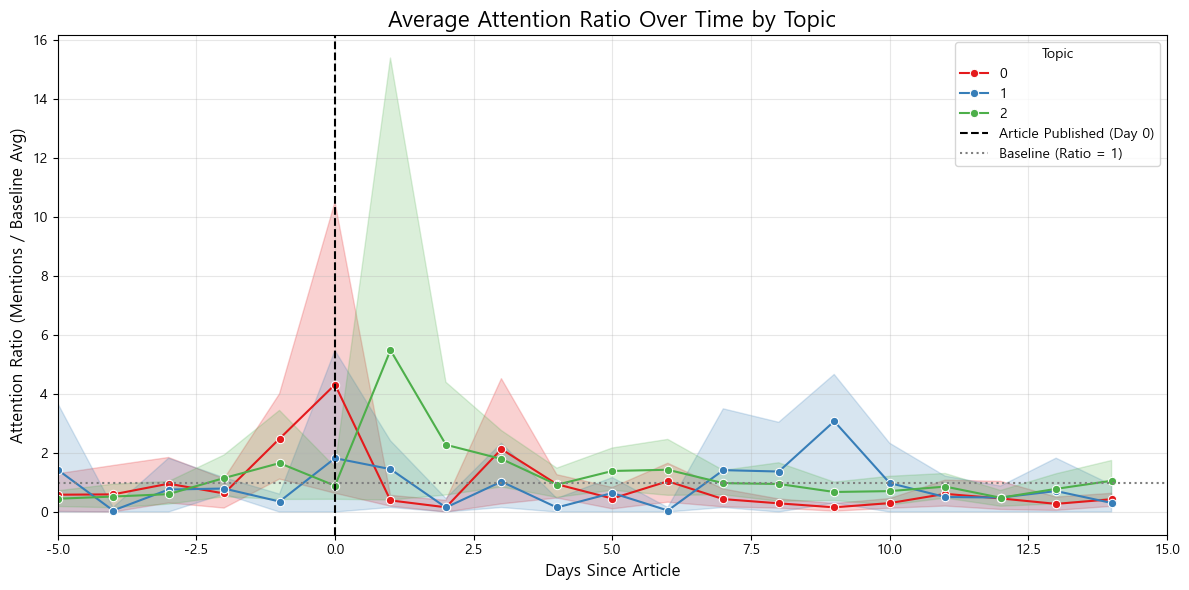

Average Days to Peak Attention by Topic:
topic
0    2.400000
1    5.666667
2    2.714286
Name: peak_day, dtype: float64


In [5]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_ratio, x='days_since_article', y='attention_ratio', hue='topic', palette='Set1', marker='o')

plt.axvline(0, color='black', linestyle='--', label='Article Published (Day 0)')
plt.axhline(1, color='gray', linestyle=':', label='Baseline (Ratio = 1)')
plt.xlim(-5, 15)

plt.title('Average Attention Ratio Over Time by Topic', fontsize=16)
plt.xlabel('Days Since Article', fontsize=12)
plt.ylabel('Attention Ratio (Mentions / Baseline Avg)', fontsize=12)
plt.legend(title='Topic')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Days to Peak Attention by Topic:")
print(df_peak.groupby('topic')['peak_day'].mean())

In [6]:
from transformers import pipeline
from tqdm import tqdm
import torch

tqdm.pandas()

device = 0 if torch.cuda.is_available() else -1

print("Loading sentiment analysis model...")
sentiment_analyzer = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=device
)

def get_sentiment(text):
    if pd.isna(text) or len(str(text).strip()) == 0:
        return np.nan
    try:
        text = str(text)[:512]
        result = sentiment_analyzer(text)[0]

        stars = int(result['label'][0])
        if stars >= 4:
            return 1 # Positive
        elif stars <= 2:
            return -1 # Negative
        else:
            return 0 # Neutral
    except Exception as e:
        return np.nan


sentiment_data = []

for idx, row in articles_df.iterrows():
    person = row['name']
    art_date = row['article_time'].normalize()
    
    start_date = art_date - timedelta(days=7)
    end_date = art_date + timedelta(days=7)
    
    mask = (all_comm_df['keyword'] == person) & (all_comm_df['time'] >= start_date) & (all_comm_df['time'] <= end_date + timedelta(days=1))
    subset = all_comm_df[mask].copy()
    subset['event_id'] = f"{person}_Event_{idx+1}"
    subset['topic'] = row['topic']
    subset['period'] = subset['time'].apply(lambda x: 'Before' if x < art_date else 'After')
    
    sentiment_data.append(subset)

df_sentiment = pd.concat(sentiment_data, ignore_index=True)

df_sentiment_sample = df_sentiment.copy()

df_sentiment_sample['sentiment_score'] = df_sentiment_sample['content'].progress_apply(get_sentiment)
# Group by Event and Period to see shifts
shift_df = df_sentiment_sample.groupby(['topic', 'event_id', 'period'])['sentiment_score'].mean().unstack()
shift_df['sentiment_shift'] = shift_df['After'] - shift_df['Before']

print("\nSentiment Shift (After - Before) by Event:")
display(shift_df)

Loading sentiment analysis model...


Device set to use cpu
100%|██████████| 1926/1926 [02:46<00:00, 11.55it/s]


Sentiment Shift (After - Before) by Event:


period                 After    Before  sentiment_shift
topic event_id                                         
0     김광규_Event_1  -0.181818 -0.368421         0.186603
      이경규_Event_14 -0.150442 -0.062500        -0.087942
      임우일_Event_2  -0.368421 -0.187500        -0.180921
      장도연_Event_3   0.004717 -0.127796         0.132513
1     남보라_Event_10 -0.812500  0.166667        -0.979167
      송지은_Event_12 -0.142857 -0.500000         0.357143
      조째즈_Event_11 -0.066667  0.075000        -0.141667
2     김장훈_Event_7  -0.175676 -0.235294         0.059618
      사유리_Event_9   0.047619 -0.423077         0.470696
      송지은_Event_13 -0.272727  0.000000        -0.272727
      이천수_Event_4  -0.318750  0.166667        -0.485417
      이천수_Event_5   0.055556 -0.647059         0.702614
      정유미_Event_6  -0.291667 -0.111111        -0.180556
      최미나수_Event_8 -0.434109 -0.242331        -0.191777

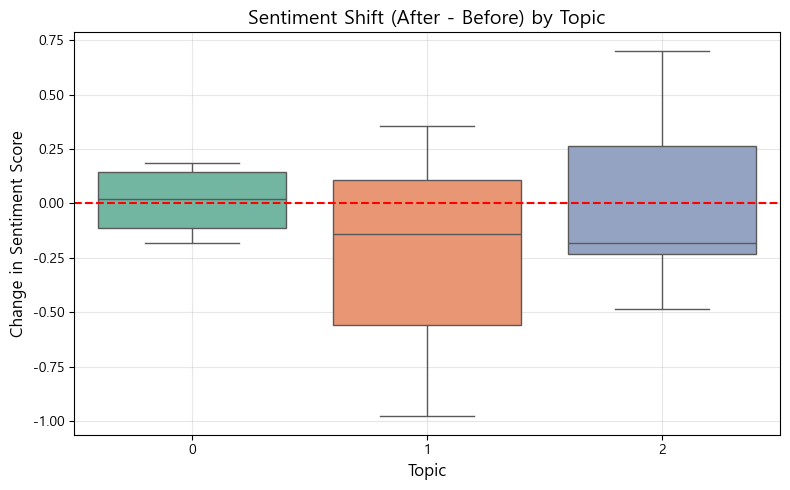

In [7]:
# Plot Average Sentiment Shift by Topic
if 'sentiment_shift' in shift_df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=shift_df.reset_index(), x='topic', y='sentiment_shift', palette='Set2')
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Sentiment Shift (After - Before) by Topic', fontsize=14)
    plt.ylabel('Change in Sentiment Score', fontsize=12)
    plt.xlabel('Topic', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()